In [15]:
import scanpy as sc
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
def dotplot(data, x, y, color, size, sizes=(0,200), colors=(-0.5,0.5), dpi=300):
    #normalize = mcolors.TwoSlopeNorm(vcenter=0, vmin=colors[0], vmax=colors[1])
    # colormap = cm.PiYG
    if colors:
        data[color]=data[color].clip(colors[0], colors[1])





    data[x]=data[x].astype("category")
    data[y]=data[y].astype("category")

    x_lab=data[x].cat.categories
    y_lab=data[y].cat.categories

    f=sns.clustermap(data.pivot(index=y, columns=x, values=color),figsize=(0.1,0.1), cmap='PiYG')

    x_lab=x_lab[f.dendrogram_col.reordered_ind]
    y_lab=y_lab[f.dendrogram_row.reordered_ind]


    data[x]=data[x].cat.reorder_categories(x_lab)
    data[y]=data[y].cat.reorder_categories(y_lab)
    data=data.sort_values([x, y])


    plt.figure(figsize=(0.3*len(x_lab),0.3*len(y_lab)), dpi=dpi)

    ax =sns.scatterplot(data=data,
                        y=y,
                        x=x,
                        hue=color,
                        palette="PiYG",
                        size=size,
                        sizes=sizes)

    ax.set_xlim(-0.5, -0.5+len(x_lab))
    ax.set_ylim(-0.5, -0.5+len(y_lab))

    ax.set_xticklabels(x_lab,rotation = 90)
    ax.legend(ncol=14,loc='lower left', bbox_to_anchor=(-0.1,-1.5),columnspacing=0.6,handletextpad=0)
    return ax



In [16]:
df=[]
for sample in ["A1", "B1", "C1", "D1", "E1", "F1", "G2", "H1","CID44971","CID4535","CID4290","1142243F","CID4465","1160920F"]:
    adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
    adata=adata[adata.obs['pathology'] !="Artefact"]
    adata=adata[adata.obs['pathology'] !="Uncertain"]
    adata=adata[adata.obs['pathology'] !=np.nan]
    sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")

    categories=adata.obs['pathology'].cat.categories
    mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
    for i in range(len(adata.uns['rank_genes_groups']['names'])):
        for j, cat in enumerate(categories):
            tf=adata.uns['rank_genes_groups']['names'][i][j]
            pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
            mean=mean_df.loc[cat, tf]
            df.append([sample, tf, cat, mean, pval, i/adata.n_vars])

df=pd.DataFrame(df, columns=['Sample','TF', 'Pathology', 'Mean', 'p_adj', 'rank'])

/Users/student/Library/Python/3.9/lib/python/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/Users/student/Library/Python/3.9/lib/python/site-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[gro

In [17]:
df['Pathology']=df['Pathology'].map(lambda x: x.lower())

/var/folders/t6/876nj23922g7ync9x5slmd0h0000gq/T/ipykernel_78624/2683913220.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['TF']=df_subset['TF'].astype("category")
/var/folders/t6/876nj23922g7ync9x5slmd0h0000gq/T/ipykernel_78624/2683913220.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['TF']=df_subset['TF'].cat.remove_unused_categories()
/var/folders/t6/876nj23922g7ync9x5slmd0h0000gq/T/ipykernel_78624/3945116380.py:11: SettingWithCopyWarning: 
A value is trying to be set on a c

<AxesSubplot: xlabel='TF', ylabel='Sample'>

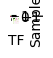

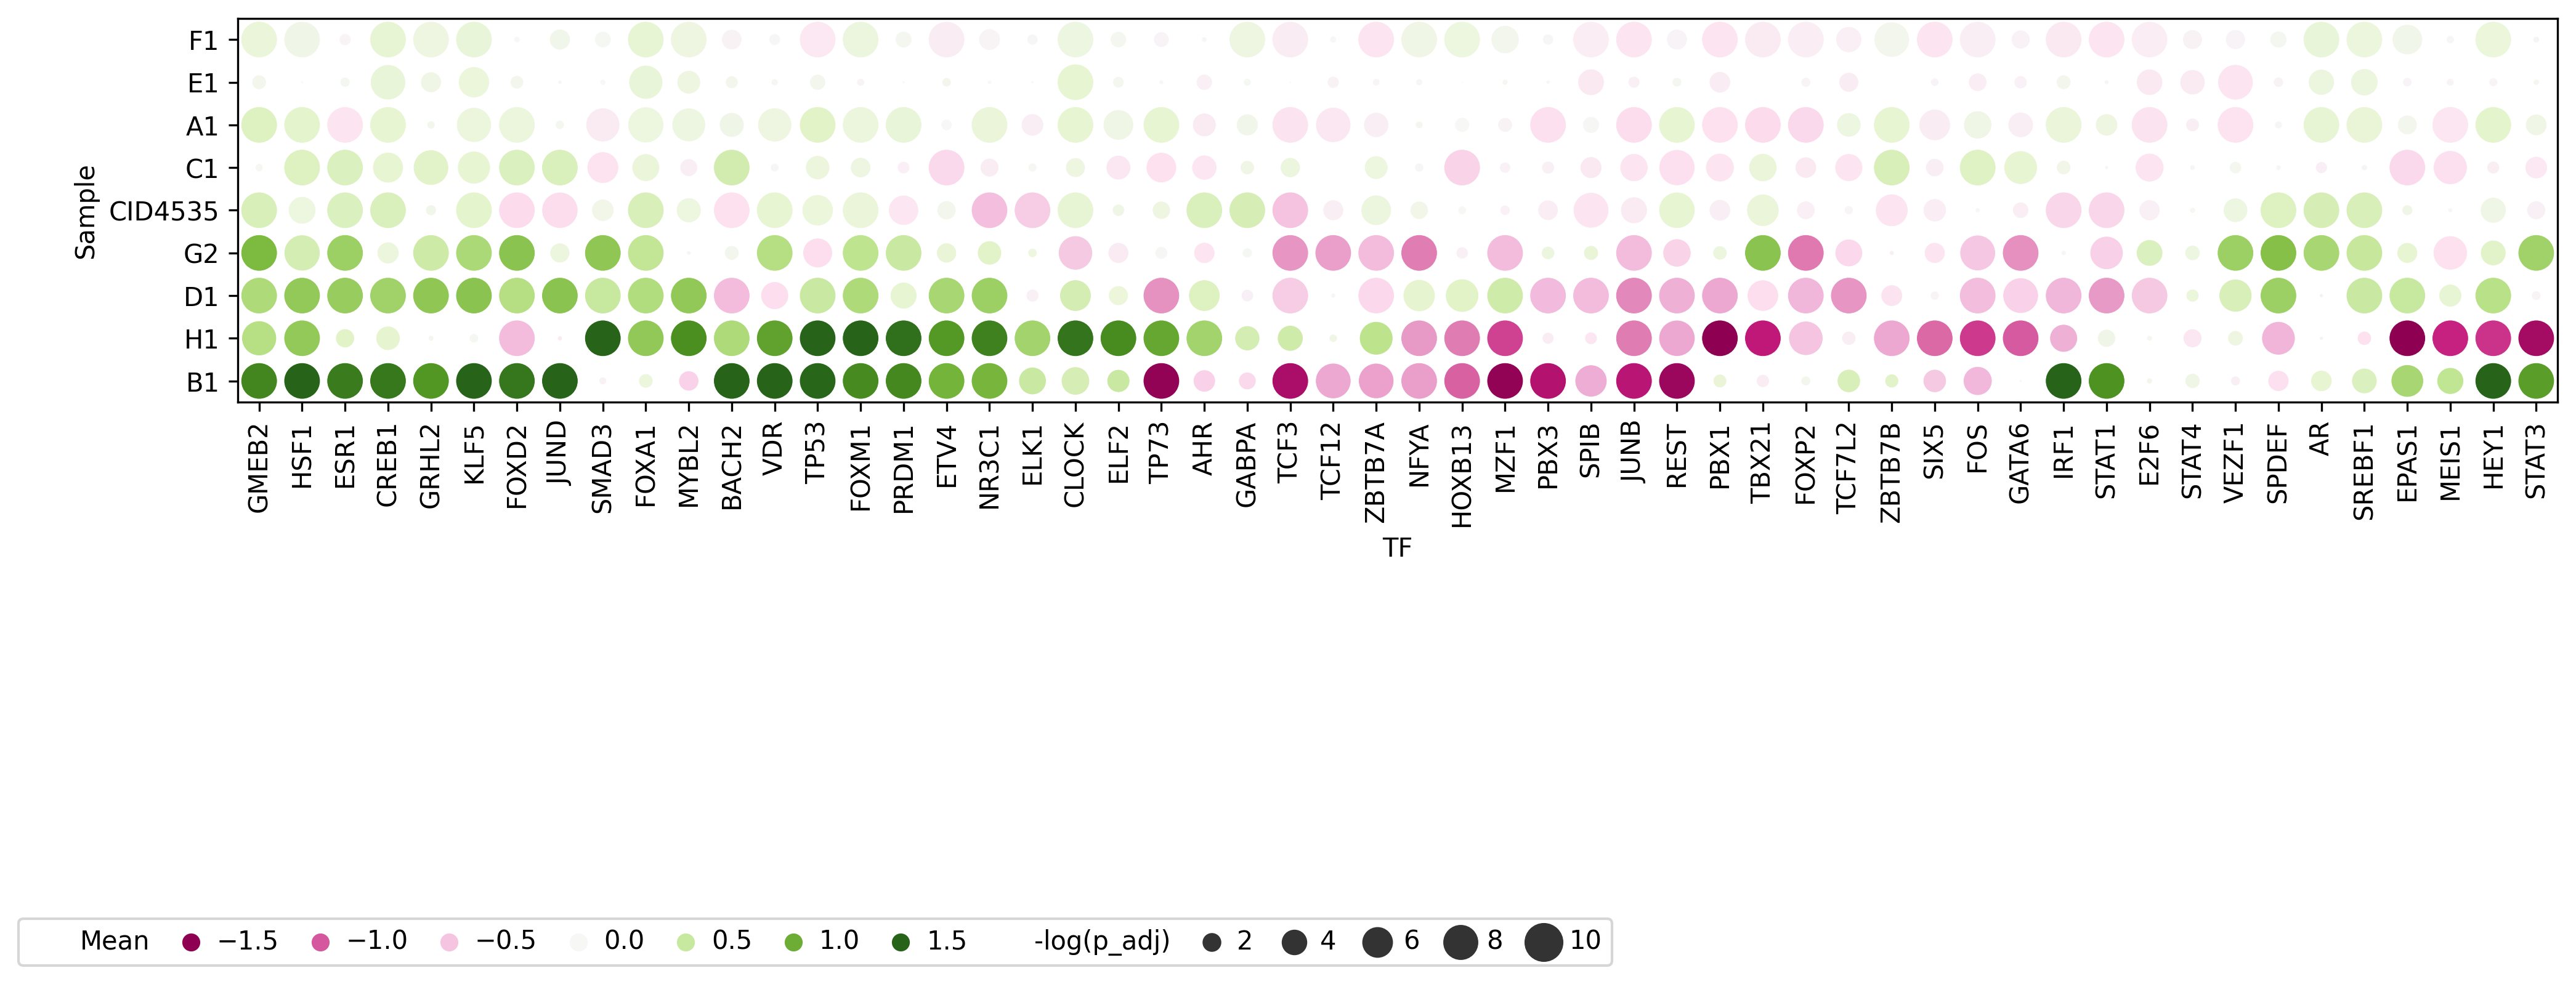

In [18]:
df['-log(p_adj)']=-np.log10(df['p_adj']+1e-10)
tfs=df.query("Pathology=='invasive cancer' and (rank<0.02 or rank>0.98)")['TF'].unique() #get top 5% for each sample
tfs=df.query("Pathology=='invasive cancer' and TF in @tfs").pivot(index="Sample", columns="TF", values="Mean").dropna(axis=1).columns #only keep tfs with in all samples
df_subset=df.query("Pathology=='invasive cancer' and TF in @tfs")

df_subset['TF']=df_subset['TF'].astype("category")
df_subset['TF']=df_subset['TF'].cat.remove_unused_categories()
dotplot(df_subset, x="TF", y='Sample', color="Mean", size="-log(p_adj)", colors=(-1.5, 1.5))


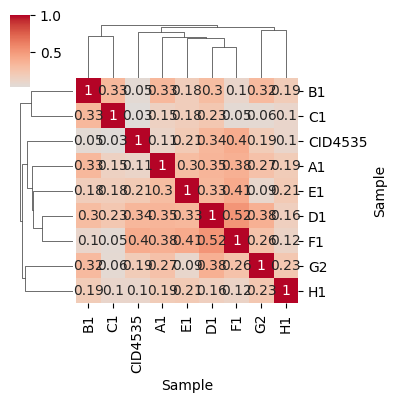

In [19]:
sns.clustermap(df.query("Pathology=='invasive cancer'").pivot(columns="Sample", index="TF", values="Mean").dropna().corr().round(2),
               cmap="coolwarm", center=0, annot=True, figsize=(4,4))

In [20]:
df[["Pathology", "Sample"]].value_counts().unstack()>0

Sample,1142243F,1160920F,A1,B1,C1,CID4290,CID4465,CID44971,CID4535,D1,E1,F1,G2,H1
Pathology,,,,,,,,,,,,,,
adipose tissue,False,True,True,True,True,False,False,False,True,False,False,False,True,True
breast glands,False,False,False,True,False,False,False,False,False,False,False,False,True,True
cancer in situ,False,False,True,False,False,False,False,False,False,False,False,False,True,True
cancer trapped in lymphocyte aggregation,False,True,False,False,False,False,False,False,False,False,False,False,False,False
connective tissue,False,False,True,True,True,False,False,False,False,True,True,True,True,True
dcis,False,True,False,False,False,False,False,True,False,False,False,False,False,False
immune infiltrate,False,False,True,False,False,False,False,False,False,True,True,True,True,True
invasive cancer,False,False,True,True,True,False,False,False,True,True,True,True,True,True
invasive cancer + adipose tissue + lymphocytes,False,False,False,False,False,False,False,False,True,False,False,False,False,False
